# 02 — Algebra Essentials

**Topic 2 of the math journey.** In lesson 1 we learned *what numbers are*. Now we learn
how to **work with letters that stand for numbers**. Algebra is the language of all later
math (calculus, linear algebra, machine learning), so we make the basic moves solid and
we prove *why* each move is allowed.

## Quick recall from lesson 1 (answers)
- $0.\overline{4} = \dfrac{4}{9}$ (block `4`, length 1, so denominator $10^1-1=9$). It is
  **rational**.
- In the $\sqrt2$ proof, "lowest terms" mattered because we showed both $p$ and $q$ are
  even — they share the factor 2. That **contradicts** "no common factor". Without
  "lowest terms" there would be no contradiction.

## What we cover today
1. Expressions, terms, like terms, and the rules that let us simplify.
2. Laws of exponents (with proofs).
3. Scientific notation (a quick, useful tool).
4. Solving linear equations — and *why* each step keeps the answer correct.
5. Solving linear inequalities — and the famous "flip the sign" rule (proved).
6. Absolute-value equations and inequalities.


## 1. Expressions, terms, and like terms

An **algebraic expression** is a mix of numbers, letters (**variables**), and the
operations $+,-,\times,\div$ and powers. Example: $3x^2 - 5x + 2x^2 + 7$.

- A **term** is a piece separated by $+$ or $-$: here the terms are $3x^2$, $-5x$,
  $2x^2$, $7$.
- The number in front is the **coefficient** (in $3x^2$ the coefficient is $3$).
- **Like terms** have the *same variable part*: $3x^2$ and $2x^2$ are like terms; $-5x$
  is different; $7$ is a constant.

**Why can we add like terms?** Because of the **distributive law** from lesson 1
($a(b+c)=ab+ac$), read backwards:
$$ 3x^2 + 2x^2 = (3+2)x^2 = 5x^2. $$
So "combining like terms" is not a new rule — it is the distributive law used in reverse.
The whole expression simplifies to $5x^2 - 5x + 7$.

*New symbol:* $x^2$ means $x\cdot x$ (a **power**: the small number is the **exponent**).


In [1]:
import sympy as sp                      # sympy = exact symbolic algebra

x = sp.symbols('x')                       # declare x as an algebraic variable (a letter)
expr = 3*x**2 - 5*x + 2*x**2 + 7          # ** means "to the power"; x**2 is x squared
print("original: ", expr)
print("simplified:", sp.simplify(expr))   # sympy collects the like terms automatically

# sp.collect groups by powers of x so you can SEE the like terms being combined:
print("collected: ", sp.collect(expr, x))


original:  5*x**2 - 5*x + 7


simplified: 5*x**2 - 5*x + 7
collected:  5*x**2 - 5*x + 7


## 2. Laws of exponents

For a real base $a$ and whole-number exponents $m, n$, the exponent $a^n$ means "multiply
$a$ by itself $n$ times":
$$ a^n = \underbrace{a \cdot a \cdots a}_{n \text{ copies}}, \qquad a^0 = 1 \ (a\neq 0). $$

From this single definition, three laws follow.

**Law 1 (product):** $\;a^m \cdot a^n = a^{m+n}$.
**Proof.** The left side is ($m$ copies of $a$) times ($n$ copies of $a$). Put them next
to each other: that is $m+n$ copies of $a$ multiplied together, which is $a^{m+n}$. ∎

**Law 2 (power of a power):** $\;(a^m)^n = a^{mn}$.
**Proof.** $(a^m)^n$ means $n$ copies of $a^m$. Each $a^m$ is $m$ copies of $a$, so in
total we have $n\times m = mn$ copies of $a$, i.e. $a^{mn}$. ∎

**Law 3 (power of a product):** $\;(ab)^n = a^n b^n$.
**Proof.** $(ab)^n$ is $n$ copies of $ab$. Using that multiplication is commutative and
associative (lesson 1), we can reorder the factors to collect all the $a$'s and all the
$b$'s: $(ab)^n = (a\cdots a)(b\cdots b) = a^n b^n$. ∎

**Negative exponents** are *defined* so Law 1 keeps working:
$$ a^{-n} = \frac{1}{a^n} \quad (a\neq 0), \qquad\text{because}\qquad a^n \cdot a^{-n}=a^{0}=1. $$


In [2]:
import sympy as sp
a, m, n = sp.symbols('a m n', positive=True)   # positive=True lets sympy use exponent laws

# sympy can CHECK each law: subtract the two sides and simplify to 0 means "always equal".
print("Law 1 holds? ", sp.simplify(a**m * a**n - a**(m+n)) == 0)
print("Law 2 holds? ", sp.powsimp((a**m)**n) == a**(m*n))
print("Law 3 holds? ", sp.simplify((a*sp.Symbol('b', positive=True))**n
                                    - a**n * sp.Symbol('b', positive=True)**n) == 0)

# Negative exponent example, kept exact (not rounded):
print("2**-3 =", sp.Rational(2)**-3)           # -> 1/8


Law 1 holds?  True
Law 2 holds?  True
Law 3 holds?  True
2**-3 = 1/8


## 3. Scientific notation

Very big or very small numbers are written as
$$ a \times 10^{k}, \qquad 1 \le |a| < 10,\ k \in \mathbb{Z}. $$
The exponent $k$ says how many places to move the decimal point.

- $5\,300\,000 = 5.3 \times 10^{6}$ (move point 6 places right).
- $0.00042 = 4.2 \times 10^{-4}$ (move point 4 places left).

This is just the exponent laws at work, and it is everywhere in science and computing
(for example, model weights and learning rates in machine learning).


In [3]:
# Python already prints numbers in scientific notation; we can format it ourselves.
big   = 5_300_000.0       # underscores are just visual separators in Python numbers
small = 0.00042

print(f"{big:.3e}")        # the 'e' format = scientific notation: 5.300e+06
print(f"{small:.3e}")      # -> 4.200e-04

# Check the meaning by reconstructing the value from a*10**k:
print(5.3 * 10**6, "==", big)
print(4.2 * 10**-4, "==", small)


5.300e+06
4.200e-04
5300000.0 == 5300000.0
0.00042 == 0.00042


## 4. Solving linear equations

A **linear equation** in one variable looks like $ax + b = 0$ (the variable appears only
to the power 1). "Solving" means finding the value of $x$ that makes it true.

We use the **properties of equality**: if two things are equal, they stay equal when we
- add the same number to both sides, or
- multiply both sides by the same **non-zero** number.

These steps never change the solution, because each one can be **undone** (add/subtract,
multiply/divide are inverse operations). That is why the new equation has *exactly the
same* solutions as the old one.

**Theorem.** If $a \neq 0$, the equation $ax + b = 0$ has exactly one solution,
$x = -\dfrac{b}{a}$.

**Proof.** Subtract $b$ from both sides: $ax = -b$. Since $a\neq 0$ it has an inverse
$a^{-1}$; multiply both sides by it: $x = -b/a$. This shows **any** solution must equal
$-b/a$ (uniqueness). And substituting back, $a(-b/a)+b = -b+b = 0$, so it really is a
solution (existence). Exactly one solution. ∎

(If $a=0$: the equation is $b=0$, which has *no* solution when $b\neq0$, and *every* $x$
when $b=0$. So $a\neq0$ is essential.)


In [4]:
import sympy as sp
x = sp.symbols('x')

# Solve a concrete linear equation 3x + 6 = 0 and check against the formula -b/a.
eq = sp.Eq(3*x + 6, 0)                 # sp.Eq(left, right) builds the equation left = right
sol = sp.solve(eq, x)                  # sp.solve returns the list of solutions
print("solutions of 3x+6=0:", sol, "  formula -b/a =", sp.Rational(-6, 3))

# A worked multi-step example: 2(x - 4) + 3 = 5x - 1
eq2 = sp.Eq(2*(x - 4) + 3, 5*x - 1)
print("solve 2(x-4)+3 = 5x-1 :", sp.solve(eq2, x))

# Verify by substitution (substitute the solution back; result should make both sides equal)
s = sp.solve(eq2, x)[0]
print("check: left =", (2*(s-4)+3), " right =", (5*s-1))


solutions of 3x+6=0: [-2]   formula -b/a = -2
solve 2(x-4)+3 = 5x-1 : [-4/3]
check: left = -23/3  right = -23/3


## 5. Linear inequalities and the "flip the sign" rule

An **inequality** uses $<, \le, >, \ge$ instead of $=$. Solving works almost the same way,
with **one special rule**:

> When you multiply or divide both sides by a **negative** number, you must **reverse**
> the inequality sign.

**Theorem.** If $a < b$ and $c < 0$, then $ac > bc$ (the sign flips).

**Proof.** From $a<b$ we get $b-a>0$ (a positive number). Now $c<0$ means $-c>0$. The
product of two positive numbers is positive, so $(b-a)(-c) > 0$, that is
$-(b-a)c > 0$, i.e. $(b-a)c < 0$. Expand: $bc - ac < 0$, so $bc < ac$, which is the same
as $ac > bc$. The sign reversed. ∎

Example: from $-2x < 6$, divide by $-2$ (negative!) and flip: $x > -3$.


In [5]:
import sympy as sp
x = sp.symbols('x', real=True)

# sympy solves inequalities and applies the flip rule for us.
print("solve -2x < 6 :", sp.solve_univariate_inequality(-2*x < 6, x, relational=True))
print("solve 3x - 1 >= 5 :", sp.solve_univariate_inequality(3*x - 1 >= 5, x, relational=True))

# Show the flip numerically: pick a < b, multiply by negative c, watch the order reverse.
a, b, cneg = 2, 5, -3
print(f"a<b? {a < b};   after *({cneg}):  a*c={a*cneg}, b*c={b*cneg};  now a*c>b*c? {a*cneg > b*cneg}")


solve -2x < 6 : -3 < x


solve 3x - 1 >= 5 : 2 <= x
a<b? True;   after *(-3):  a*c=-6, b*c=-15;  now a*c>b*c? True


## 6. Absolute-value equations and inequalities

Recall $|t|$ = distance of $t$ from $0$ (lesson 1). So:

- $|t| = d$ (with $d\ge 0$) means $t = d$ **or** $t = -d$ (two points at distance $d$).
- $|t| < d$ means $-d < t < d$ (a band around 0).
- $|t| > d$ means $t < -d$ **or** $t > d$ (outside the band).

**Example (equation).** $|x-1| = 4 \Rightarrow x-1 = 4$ or $x-1 = -4 \Rightarrow x=5$ or
$x=-3$.

**Example (inequality).** $|x-1| < 4 \Rightarrow -4 < x-1 < 4 \Rightarrow -3 < x < 5$,
the interval $(-3,5)$. This reads as "all points within distance 4 of the number 1".


solve |x-1| = 4 : [-3, 5]
solve |x-1| < 4 : (-3 < x) & (x < 5)


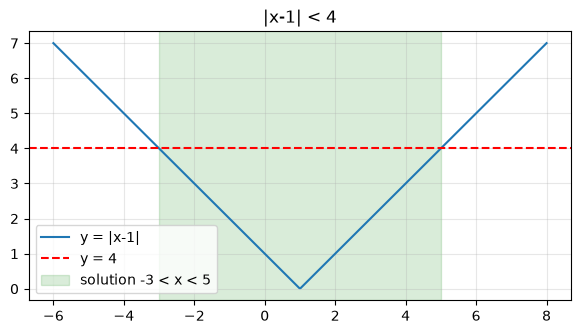

In [6]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.symbols('x', real=True)
print("solve |x-1| = 4 :", sp.solve(sp.Eq(sp.Abs(x-1), 4), x))
print("solve |x-1| < 4 :", sp.solve_univariate_inequality(sp.Abs(x-1) < 4, x, relational=True))

# Picture: y = |x-1| with the line y=4. The solution of |x-1|<4 is where the V is BELOW 4.
xv = np.linspace(-6, 8, 400)              # 400 x-values for a smooth curve
yv = np.abs(xv - 1)                       # np.abs gives |x-1| for every value
plt.figure(figsize=(7, 3.5))
plt.plot(xv, yv, label="y = |x-1|")
plt.axhline(4, color="red", ls="--", label="y = 4")
plt.axvspan(-3, 5, color="green", alpha=0.15, label="solution -3 < x < 5")  # shaded band
plt.legend(); plt.grid(True, alpha=0.3); plt.title("|x-1| < 4"); plt.show()


## Summary — what you should now be able to do

1. **Simplify** expressions by combining like terms (= distributive law backwards).
2. Use the **laws of exponents** and explain *why* each one is true.
3. Read and write **scientific notation**.
4. **Solve linear equations** and justify each step with the properties of equality;
   know $ax+b=0$ has the unique solution $-b/a$ when $a\neq0$.
5. **Solve linear inequalities**, remembering to **flip the sign** on multiply/divide by a
   negative (and prove why).
6. Solve **absolute-value** equations and inequalities, and picture them on the line.


## Exercises (20)

Try each one yourself first. The last block asks for proofs.

**A. Simplify (combine like terms / exponents)**
1. Simplify $4a + 7 - 2a + 5$.
2. Simplify $3x^2 - x + 5x^2 + 4x - 9$.
3. Simplify $x^3 \cdot x^5$ and $(y^2)^4$ using the exponent laws.
4. Simplify $\dfrac{a^7}{a^3}$ and write $2^{-4}$ as a fraction.
5. Simplify $(2x^2 y)^3$.

**B. Scientific notation & evaluation**
6. Write $0.00067$ and $920000$ in scientific notation.
7. Write $3.5 \times 10^{-3}$ as an ordinary decimal.
8. Compute $(2\times10^{5})(4\times10^{3})$ and give the answer in scientific notation.
9. Evaluate $5 + 2(3 - 8)^2$ using the correct order of operations.
10. Evaluate the expression $2x^2 - 3x + 1$ at $x = -2$.

**C. Equations & inequalities (solve)**
11. Solve $5x - 3 = 2x + 9$.
12. Solve $\dfrac{x}{2} + 4 = 1$.
13. Solve the inequality $-3x + 1 \le 7$ (watch the sign!).
14. Solve $|2x - 6| = 10$.
15. Solve $|x + 2| < 5$ and write the answer as an interval.

**D. Proofs / explanations (raise the bar)**
16. Using the definition $a^n = a\cdots a$ ($n$ copies), prove $a^m \cdot a^n = a^{m+n}$ for natural $m,n$.
17. Prove that $\dfrac{a^m}{a^n} = a^{m-n}$ for $a\neq 0$ and $m>n$. (Hint: use Law 1.)
18. Prove: if $a < b$ then $a + c < b + c$ for every real $c$. (Use: a number is positive iff it has the form "bigger minus smaller".)
19. Prove that the equation $ax + b = c$ (with $a\neq0$) has exactly one solution, and find it.
20. Prove that $|x - 1| < 4$ is equivalent to $-3 < x < 5$. (Use the meaning $-d < t < d$.)


In [7]:
# Your work for exercises 1-5 (simplify). Check with sympy: sp.simplify(...), sp.expand(...).


In [8]:
# Your work for exercises 6-10 (scientific notation & evaluation).


In [9]:
# Your work for exercises 11-15 (solve). Check with sp.solve / sp.solve_univariate_inequality.


In [10]:
# Your work for exercises 16-20 (proofs). Write proofs in a markdown cell; use code only to test.


## How to run this notebook with `uv`

From the project folder `C:\dev\math`:

```powershell
uv sync                 # install dependencies (only needed the first time / after changes)
uv run jupyter lab      # open JupyterLab, then open notebooks/02-algebra-essentials.ipynb
```

No new libraries were needed this time (we reused numpy, sympy, matplotlib). If a later
lesson needs one, add it with `uv add <name>`.
